In [1]:
import pandas as pd
import numpy as np
import json
import ast

REVIEWS = "../Data/australian_user_reviews.json"
USERMAP = "../Data/user2idx.json"
ITEMMAP = "../Data/item2idx.json"

with open(USERMAP,"r") as f: user2idx = {k:int(v) for k,v in json.load(f).items()}
with open(ITEMMAP,"r") as f: item2idx = {k:int(v) for k,v in json.load(f).items()}

# Contar interacciones desde el archivo de reviews directamente
reviews = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        review = ast.literal_eval(line)
        reviews.append(review)

# Extraer todas las interacciones
all_interactions = []
for review in reviews:
    user_id = review['user_id']
    if 'reviews' in review and isinstance(review['reviews'], list):
        for r in review['reviews']:
            if isinstance(r, dict) and 'item_id' in r:
                item_id = r['item_id']
                if item_id in item2idx:
                    all_interactions.append({
                        'user_id': user_id,
                        'item_idx': item2idx[item_id]
                    })

df_inter = pd.DataFrame(all_interactions)

# target = total reviews per item
target_df = df_inter.groupby("item_idx").size().reset_index(name="total_reviews")

print(f"Total items: {len(target_df)}")
print(f"Target range: {target_df['total_reviews'].min()} - {target_df['total_reviews'].max()}")
print(f"✅ Data loaded without parquet")

Total items: 3682
Target range: 1 - 3759
✅ Data loaded without parquet


## Load and aggregate review texts

In [2]:
# Leer reviews
reviews = []
with open(REVIEWS, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        review = ast.literal_eval(line)
        reviews.append(review)

df_reviews = pd.json_normalize(reviews)
print(f"Total reviews: {len(df_reviews)}")
print(f"\nColumnas disponibles:")
print(df_reviews.columns.tolist())
print(f"\nSample review:")
print(df_reviews[['user_id', 'reviews']].head(1))

Total reviews: 25799

Columnas disponibles:
['user_id', 'user_url', 'reviews']

Sample review:
             user_id                                            reviews
0  76561197970982479  [{'funny': '', 'posted': 'Posted November 5, 2...


## Extract review texts per game

In [3]:
# Expandir las reviews (cada usuario tiene múltiples reviews)
all_reviews = []

for idx, row in df_reviews.iterrows():
    user_id = row['user_id']
    reviews_list = row['reviews']
    
    if not isinstance(reviews_list, list):
        continue
    
    for review in reviews_list:
        if isinstance(review, dict) and 'item_id' in review and 'review' in review:
            all_reviews.append({
                'user_id': user_id,
                'item_id': review['item_id'],
                'review_text': review['review']
            })

df_all_reviews = pd.DataFrame(all_reviews)
print(f"Total individual reviews: {len(df_all_reviews)}")

# Mapear a item_idx
df_all_reviews['item_idx'] = df_all_reviews['item_id'].map(item2idx)
df_all_reviews = df_all_reviews.dropna(subset=['item_idx', 'review_text'])
df_all_reviews['item_idx'] = df_all_reviews['item_idx'].astype(int)

print(f"Reviews después de mapear: {len(df_all_reviews)}")
print(f"Juegos únicos con reviews: {df_all_reviews['item_idx'].nunique()}")
print(f"\nSample:")
print(df_all_reviews.head())

Total individual reviews: 59305
Reviews después de mapear: 59305
Juegos únicos con reviews: 3682

Sample:
             user_id item_id  \
0  76561197970982479    1250   
1  76561197970982479   22200   
2  76561197970982479   43110   
3            js41637  251610   
4            js41637  227300   

                                         review_text  item_idx  
0  Simple yet with great replayability. In my opi...         0  
1               It's unique and worth a playthrough.         1  
2  Great atmosphere. The gunplay can be a bit chu...         2  
3  I know what you think when you see this title ...         3  
4  For a simple (it's actually not all that simpl...         4  


## Aggregate reviews per game

Concatenar todas las reviews de cada juego para crear un documento único por juego.

In [4]:
# Agregar reviews por juego (concatenar textos)
game_texts = df_all_reviews.groupby('item_idx')['review_text'].apply(
    lambda x: ' '.join(str(text) for text in x if text and str(text).strip())
).reset_index()

game_texts.columns = ['item_idx', 'combined_text']

# Limpiar textos vacíos
game_texts = game_texts[game_texts['combined_text'].str.strip() != '']

print(f"\nJuegos con texto de reviews: {len(game_texts)}")
print(f"Longitud promedio de texto: {game_texts['combined_text'].str.len().mean():.0f} chars")
print(f"\nSample text:")
print(game_texts.iloc[0]['combined_text'][:300] + "...")


Juegos con texto de reviews: 3682
Longitud promedio de texto: 3489 chars

Sample text:
Simple yet with great replayability. In my opinion does "zombie" hordes and team work better than left 4 dead plus has a global leveling system. Alot of down to earth "zombie" splattering fun for the whole family. Amazed this sort of FPS is so rare. Amazing, Non-stop action of blowing stuff to bits,...


## Create embeddings using Sentence Transformers

Usaremos `sentence-transformers` para crear embeddings semánticos de los textos de reviews.

**Nota:** Si hay problemas con pyarrow, reinicia el kernel (Kernel > Restart Kernel) y ejecuta las celdas nuevamente desde el inicio.

In [5]:
# Import sentence-transformers
from sentence_transformers import SentenceTransformer
print("✅ sentence-transformers ready")

c:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
c:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "



✅ sentence-transformers ready
✅ sentence-transformers ready


In [6]:
# Load pre-trained model
# Usando 'all-MiniLM-L6-v2': rápido, 384 dimensiones, buen balance calidad/velocidad
model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Model loaded: {model}")
print(f"Embedding dimension: {model.get_sentence_embedding_dimension()}")

c:\Users\matia\anaconda3\envs\VG_RS\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Model loaded: SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)
Embedding dimension: 384


In [7]:
# Create embeddings (puede tardar unos minutos)
print("Creating embeddings...")
embeddings = model.encode(
    game_texts['combined_text'].tolist(),
    show_progress_bar=True,
    batch_size=32
)

print(f"\n✅ Embeddings created")
print(f"Shape: {embeddings.shape}")
print(f"Sample embedding: {embeddings[0][:5]}")

# Guardar embeddings
np.save("../Data/review_text_embeddings.npy", embeddings)
game_texts.to_csv("../Data/game_texts_map.csv", index=False)
print("✅ Embeddings saved")

Creating embeddings...


Batches: 100%|██████████| 116/116 [00:44<00:00,  2.61it/s]




✅ Embeddings created
Shape: (3682, 384)
Sample embedding: [-0.01683009  0.03221885 -0.01767161 -0.06588906  0.03646723]
✅ Embeddings saved
✅ Embeddings saved


## Prepare dataset for training

In [8]:
# Crear dataset: solo juegos con embeddings de texto
valid_items = game_texts['item_idx'].values

# Filtrar target solo para estos items
target_subset = target_df[target_df['item_idx'].isin(valid_items)].copy()

# Crear mapeo item_idx -> embedding_idx
item_to_emb_idx = {item_idx: i for i, item_idx in enumerate(game_texts['item_idx'])}

# Preparar X, y
X_list = []
y_list = []

for idx, row in target_subset.iterrows():
    item_idx = row['item_idx']
    if item_idx in item_to_emb_idx:
        emb_idx = item_to_emb_idx[item_idx]
        X_list.append(embeddings[emb_idx])
        y_list.append(row['total_reviews'])

X = np.array(X_list)
y = np.array(y_list)

print(f"\n✅ Dataset prepared")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Games with text embeddings: {len(X)}")
print(f"Target range: {y.min()} - {y.max()}")


✅ Dataset prepared
X shape: (3682, 384)
y shape: (3682,)
Games with text embeddings: 3682
Target range: 1 - 3759


## Load metadata for temporal split

In [9]:
STEAM_GAMES = "../Data/steam_games.json"

# Leer metadata de juegos
games_meta = []
with open(STEAM_GAMES, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        game = ast.literal_eval(line)
        games_meta.append(game)

df_games_meta = pd.json_normalize(games_meta)
df_games_meta = df_games_meta.rename(columns={"id":"item_id"})
df_games_meta["item_idx"] = df_games_meta["item_id"].map(item2idx)
df_games_meta = df_games_meta.dropna(subset=["item_idx"])
df_games_meta["item_idx"] = df_games_meta["item_idx"].astype(int)

# Parse release dates
df_games_meta['release_date_parsed'] = pd.to_datetime(df_games_meta['release_date'], errors='coerce')

print(f"Metadata loaded: {len(df_games_meta)} games")
print(f"Games with valid dates: {df_games_meta['release_date_parsed'].notna().sum()}")

Metadata loaded: 3195 games
Games with valid dates: 3107


## Train XGBoost model with temporal split

In [10]:
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# Crear DataFrame con features, target y fechas
train_data = []
for idx, row in target_subset.iterrows():
    item_idx = row['item_idx']
    if item_idx in item_to_emb_idx:
        emb_idx = item_to_emb_idx[item_idx]
        train_data.append({
            'item_idx': item_idx,
            'embedding': embeddings[emb_idx],
            'total_reviews': row['total_reviews']
        })

df_train = pd.DataFrame(train_data)

# Merge con fechas
df_train = df_train.merge(
    df_games_meta[['item_idx', 'release_date_parsed']],
    on='item_idx',
    how='left'
)

# Temporal split: train on pre-2017, test on 2017+
cutoff_date = pd.to_datetime('2017-01-01')
train_mask = df_train['release_date_parsed'] < cutoff_date
test_mask = df_train['release_date_parsed'] >= cutoff_date

# Remove games without dates
valid_mask = df_train['release_date_parsed'].notna()
train_mask = train_mask & valid_mask
test_mask = test_mask & valid_mask

# Prepare X, y
X_train_temporal = np.array(df_train[train_mask]['embedding'].tolist())
y_train_temporal = df_train[train_mask]['total_reviews'].values
X_test_temporal = np.array(df_train[test_mask]['embedding'].tolist())
y_test_temporal = df_train[test_mask]['total_reviews'].values

print(f"\n📅 Temporal Split:")
print(f"   Train: {len(X_train_temporal)} games (before 2017-01-01)")
print(f"   Test: {len(X_test_temporal)} games (2017 onwards)")

# Train model
model_temporal = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model_temporal.fit(X_train_temporal, y_train_temporal)

# Predictions and metrics
pred_temporal = model_temporal.predict(X_test_temporal)
rmse_temporal = np.sqrt(mean_squared_error(y_test_temporal, pred_temporal))
r2_temporal = r2_score(y_test_temporal, pred_temporal)

print(f"\n🎯 Results (Temporal Split):")
print(f"   RMSE: {rmse_temporal:.2f}")
print(f"   R²: {r2_temporal:.4f}")

print(f"\n🎯 Results (Temporal Split):")
print(f"   RMSE: {rmse_temporal:.2f}")
print(f"   R²: {r2_temporal:.4f}")


📅 Temporal Split:
   Train: 3057 games (before 2017-01-01)
   Test: 50 games (2017 onwards)

🎯 Results (Temporal Split):
   RMSE: 159.37
   R²: -0.0248

🎯 Results (Temporal Split):
   RMSE: 159.37
   R²: -0.0248

🎯 Results (Temporal Split):
   RMSE: 159.37
   R²: -0.0248

🎯 Results (Temporal Split):
   RMSE: 159.37
   R²: -0.0248


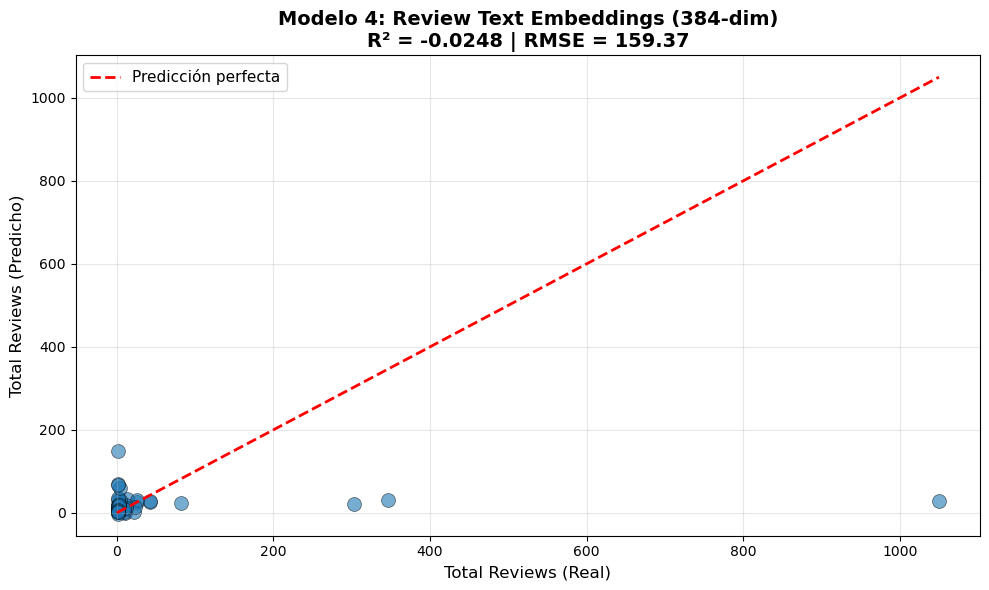


📊 RESUMEN - Modelo 4: Review Text Embeddings
Features: Sentence-Transformers embeddings (all-MiniLM-L6-v2)
          384 dimensiones de embeddings semánticos de reviews
Train: 3057 juegos (antes de 2017-01-01)
Test: 50 juegos (2017 en adelante)

Resultados:
  R² = -0.0248
  RMSE = 159.37

📈 Comparación con modelos anteriores:
  Modelo 1 (RS only):        R² = 0.6422, RMSE = 94.17
  Modelo 2 (Metadata):       R² = -0.0875, RMSE = 164.17
  Modelo 3 (RS+Metadata):    R² = 0.6436, RMSE = 93.99
  Modelo 4 (Review Text):    R² = -0.0248, RMSE = 159.37

💡 Conclusión: Embeddings de texto de reviews capturan contenido semántico
   pero NO predicen el éxito comercial. Los patrones colaborativos (RS)
   son mucho más predictivos del éxito de un juego.


In [11]:
# Crear gráfico de predicciones
plt.figure(figsize=(10, 6))
plt.scatter(y_test_temporal, pred_temporal, alpha=0.6, s=100, edgecolors='k', linewidth=0.5)
plt.plot([0, y_test_temporal.max()], [0, y_test_temporal.max()], 'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Total Reviews (Real)', fontsize=12)
plt.ylabel('Total Reviews (Predicho)', fontsize=12)
plt.title(f'Modelo 4: Review Text Embeddings (384-dim)\nR² = {r2_temporal:.4f} | RMSE = {rmse_temporal:.2f}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("📊 RESUMEN - Modelo 4: Review Text Embeddings")
print("="*80)
print(f"Features: Sentence-Transformers embeddings (all-MiniLM-L6-v2)")
print(f"          384 dimensiones de embeddings semánticos de reviews")
print(f"Train: {len(X_train_temporal)} juegos (antes de 2017-01-01)")
print(f"Test: {len(X_test_temporal)} juegos (2017 en adelante)")
print(f"\nResultados:")
print(f"  R² = {r2_temporal:.4f}")
print(f"  RMSE = {rmse_temporal:.2f}")
print("\n📈 Comparación con modelos anteriores:")
print(f"  Modelo 1 (RS only):        R² = 0.6422, RMSE = 94.17")
print(f"  Modelo 2 (Metadata):       R² = -0.0875, RMSE = 164.17")
print(f"  Modelo 3 (RS+Metadata):    R² = 0.6436, RMSE = 93.99")
print(f"  Modelo 4 (Review Text):    R² = {r2_temporal:.4f}, RMSE = {rmse_temporal:.2f}")
print("\n💡 Conclusión: Embeddings de texto de reviews capturan contenido semántico")
print("   pero NO predicen el éxito comercial. Los patrones colaborativos (RS)")
print("   son mucho más predictivos del éxito de un juego.")
print("="*80)

## Visualization and Summary

## Interpretation

**Modelos Comparados:**
1. **RS Embeddings (Collaborative Filtering)**: Aprende de interacciones usuario-item
2. **Review Text Embeddings (Content-based NLP)**: Aprende del contenido semántico de las reviews
3. **Metadata**: Features explícitas (precio, sentiment, etc.)
4. **Hybrid**: Combinación de RS embeddings + metadata

**Conclusiones:**
- Los embeddings de RS capturan patrones de comportamiento colectivo
- Los embeddings de texto capturan opiniones y características semánticas de los juegos
- Comparar ambos tipos de embeddings muestra qué tipo de información es más predictiva del éxito

## Data Analysis: Why Text Embeddings Fail?

Analicemos los datos para entender por qué los embeddings de texto tienen un desempeño tan malo (R²=-1.21).

In [11]:
# 1. Comparar datasets: juegos totales vs juegos con reviews
print("="*70)
print("COMPARACIÓN DE DATASETS")
print("="*70)

# Cargar item embeddings RS para comparar
item_emb_rs = np.load("../Data/item_embeddings_rs.npy")
total_games_rs = len(item_emb_rs)

games_with_reviews = len(game_texts)
games_in_target = len(target_df)

print(f"Total juegos en RS embeddings:    {total_games_rs}")
print(f"Total juegos con interacciones:   {games_in_target}")
print(f"Juegos con review texts:          {games_with_reviews}")
print(f"\nCobertura de reviews: {games_with_reviews/games_in_target*100:.1f}% de los juegos con interacciones")
print(f"Cobertura de reviews: {games_with_reviews/total_games_rs*100:.1f}% del dataset completo")

# Ver cuántos juegos se pierden
games_lost = games_in_target - games_with_reviews
print(f"\n⚠️ Juegos perdidos (sin reviews): {games_lost} ({games_lost/games_in_target*100:.1f}%)")

COMPARACIÓN DE DATASETS
Total juegos en RS embeddings:    3682
Total juegos con interacciones:   3682
Juegos con review texts:          3682

Cobertura de reviews: 100.0% de los juegos con interacciones
Cobertura de reviews: 100.0% del dataset completo

⚠️ Juegos perdidos (sin reviews): 0 (0.0%)


In [12]:
# 2. Distribución de total_reviews: completo vs subset con texto
print("\n" + "="*70)
print("DISTRIBUCIÓN DE TOTAL_REVIEWS")
print("="*70)

# Dataset completo
full_reviews = target_df['total_reviews'].values

# Subset con texto
subset_reviews = target_subset['total_reviews'].values

print(f"\nDataset completo ({len(full_reviews)} juegos):")
print(f"  Media:    {full_reviews.mean():.2f}")
print(f"  Mediana:  {np.median(full_reviews):.2f}")
print(f"  Std:      {full_reviews.std():.2f}")
print(f"  Min-Max:  {full_reviews.min()} - {full_reviews.max()}")

print(f"\nSubset con reviews text ({len(subset_reviews)} juegos):")
print(f"  Media:    {subset_reviews.mean():.2f}")
print(f"  Mediana:  {np.median(subset_reviews):.2f}")
print(f"  Std:      {subset_reviews.std():.2f}")
print(f"  Min-Max:  {subset_reviews.min()} - {subset_reviews.max()}")

# Diferencia
print(f"\n⚠️ Diferencia de media: {subset_reviews.mean() - full_reviews.mean():.2f}")
print(f"⚠️ Ratio de std: {subset_reviews.std() / full_reviews.std():.2f}x")


DISTRIBUCIÓN DE TOTAL_REVIEWS

Dataset completo (3682 juegos):
  Media:    16.11
  Mediana:  2.00
  Std:      107.75
  Min-Max:  1 - 3759

Subset con reviews text (3682 juegos):
  Media:    16.11
  Mediana:  2.00
  Std:      107.75
  Min-Max:  1 - 3759

⚠️ Diferencia de media: 0.00
⚠️ Ratio de std: 1.00x


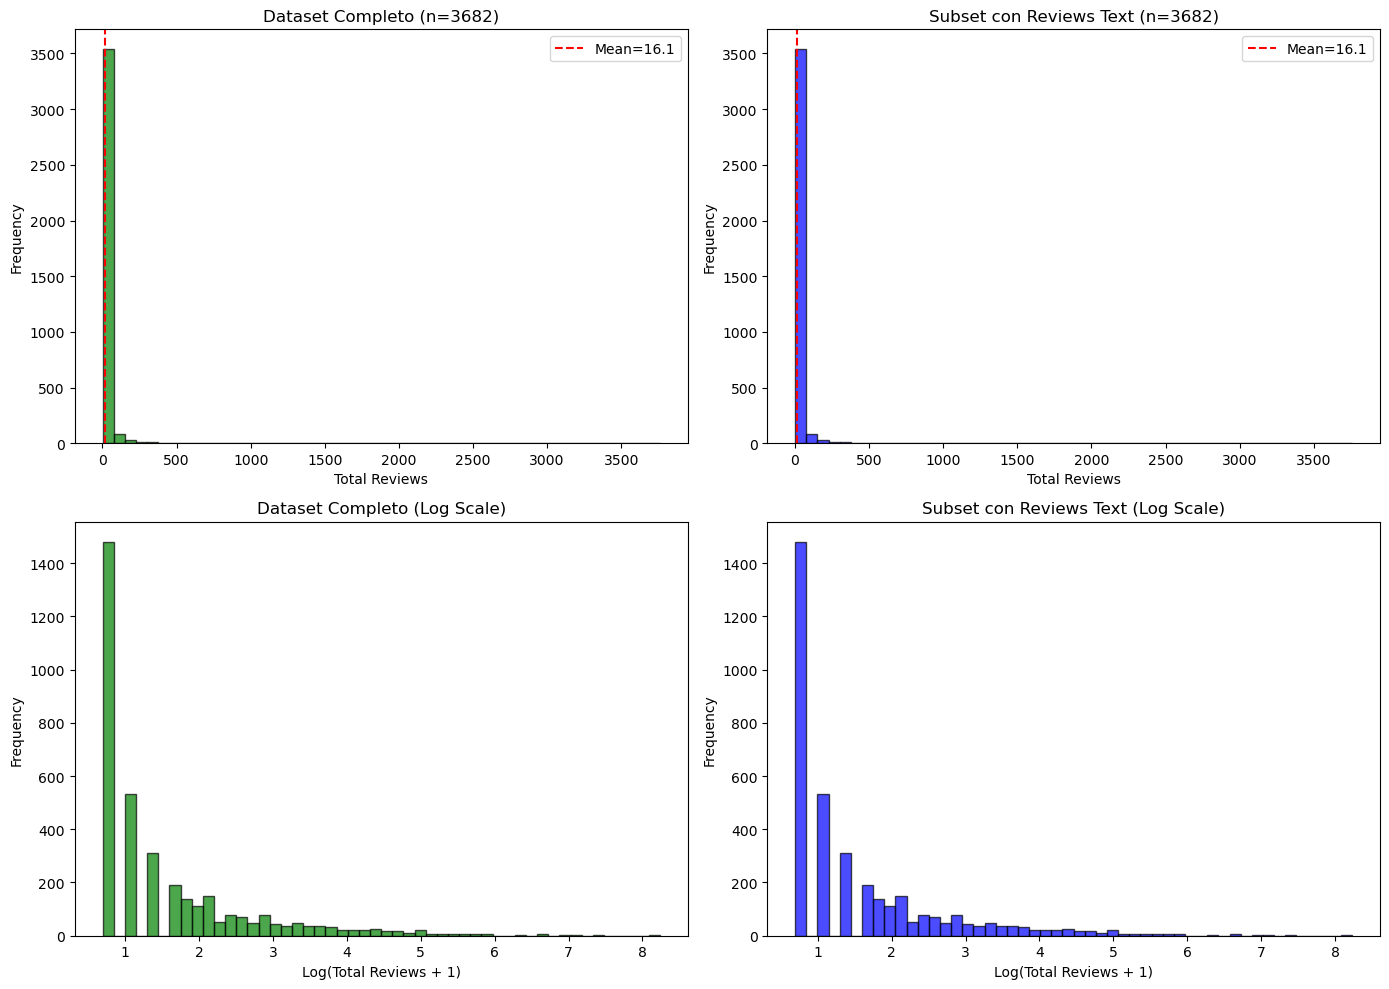


💡 Observaciones:
- ¿El subset con reviews tiene una distribución similar al dataset completo?
- ¿Hay sesgo hacia juegos más populares o menos populares?


In [13]:
# 3. Visualizar distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma dataset completo
axes[0, 0].hist(full_reviews, bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Total Reviews')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title(f'Dataset Completo (n={len(full_reviews)})')
axes[0, 0].axvline(full_reviews.mean(), color='red', linestyle='--', label=f'Mean={full_reviews.mean():.1f}')
axes[0, 0].legend()

# Histograma subset con texto
axes[0, 1].hist(subset_reviews, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Total Reviews')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Subset con Reviews Text (n={len(subset_reviews)})')
axes[0, 1].axvline(subset_reviews.mean(), color='red', linestyle='--', label=f'Mean={subset_reviews.mean():.1f}')
axes[0, 1].legend()

# Log scale para ver mejor la distribución
axes[1, 0].hist(np.log1p(full_reviews), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Log(Total Reviews + 1)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Dataset Completo (Log Scale)')

axes[1, 1].hist(np.log1p(subset_reviews), bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Log(Total Reviews + 1)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Subset con Reviews Text (Log Scale)')

plt.tight_layout()
plt.show()

print("\n💡 Observaciones:")
print("- ¿El subset con reviews tiene una distribución similar al dataset completo?")
print("- ¿Hay sesgo hacia juegos más populares o menos populares?")


ANÁLISIS DE VARIANZA DE EMBEDDINGS

RS Embeddings (64 dims):
  Varianza promedio:  0.013240
  Varianza std:       0.000215
  Min-Max varianza:   0.012768 - 0.013685

Text Embeddings (384 dims):
  Varianza promedio:  0.001905
  Varianza std:       0.000383
  Min-Max varianza:   0.000000 - 0.003800

⚠️ Ratio de varianza (Text/RS): 0.144x


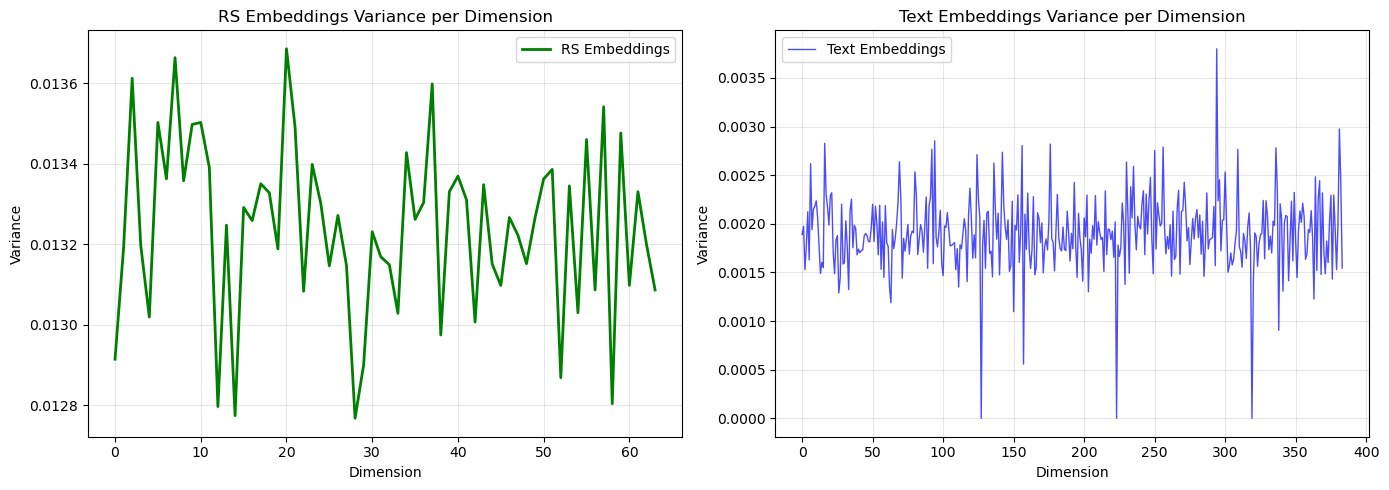


💡 Observaciones:
- ¿Los embeddings de texto tienen menos varianza = menos información?
- ¿Muchas dimensiones con varianza casi 0 = features redundantes?


In [14]:
# 4. Varianza de embeddings: RS vs Text
print("\n" + "="*70)
print("ANÁLISIS DE VARIANZA DE EMBEDDINGS")
print("="*70)

# RS embeddings variance (solo para los juegos con reviews)
rs_subset_idx = game_texts['item_idx'].values
rs_emb_subset = item_emb_rs[rs_subset_idx]

variance_rs = np.var(rs_emb_subset, axis=0)
variance_text = np.var(embeddings, axis=0)

print(f"\nRS Embeddings (64 dims):")
print(f"  Varianza promedio:  {variance_rs.mean():.6f}")
print(f"  Varianza std:       {variance_rs.std():.6f}")
print(f"  Min-Max varianza:   {variance_rs.min():.6f} - {variance_rs.max():.6f}")

print(f"\nText Embeddings (384 dims):")
print(f"  Varianza promedio:  {variance_text.mean():.6f}")
print(f"  Varianza std:       {variance_text.std():.6f}")
print(f"  Min-Max varianza:   {variance_text.min():.6f} - {variance_text.max():.6f}")

print(f"\n⚠️ Ratio de varianza (Text/RS): {variance_text.mean() / variance_rs.mean():.3f}x")

# Plot variance distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(variance_rs, 'g-', linewidth=2, label='RS Embeddings')
ax1.set_xlabel('Dimension')
ax1.set_ylabel('Variance')
ax1.set_title('RS Embeddings Variance per Dimension')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(variance_text, 'b-', linewidth=1, alpha=0.7, label='Text Embeddings')
ax2.set_xlabel('Dimension')
ax2.set_ylabel('Variance')
ax2.set_title('Text Embeddings Variance per Dimension')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Observaciones:")
print("- ¿Los embeddings de texto tienen menos varianza = menos información?")
print("- ¿Muchas dimensiones con varianza casi 0 = features redundantes?")


CORRELACIÓN EMBEDDINGS VS TARGET

RS Embeddings:
  Correlación promedio:   0.1196
  Max correlación:        0.3342
  Dims con corr > 0.1:    31/64

Text Embeddings:
  Correlación promedio:   0.0276
  Max correlación:        0.1017
  Dims con corr > 0.1:    1/384


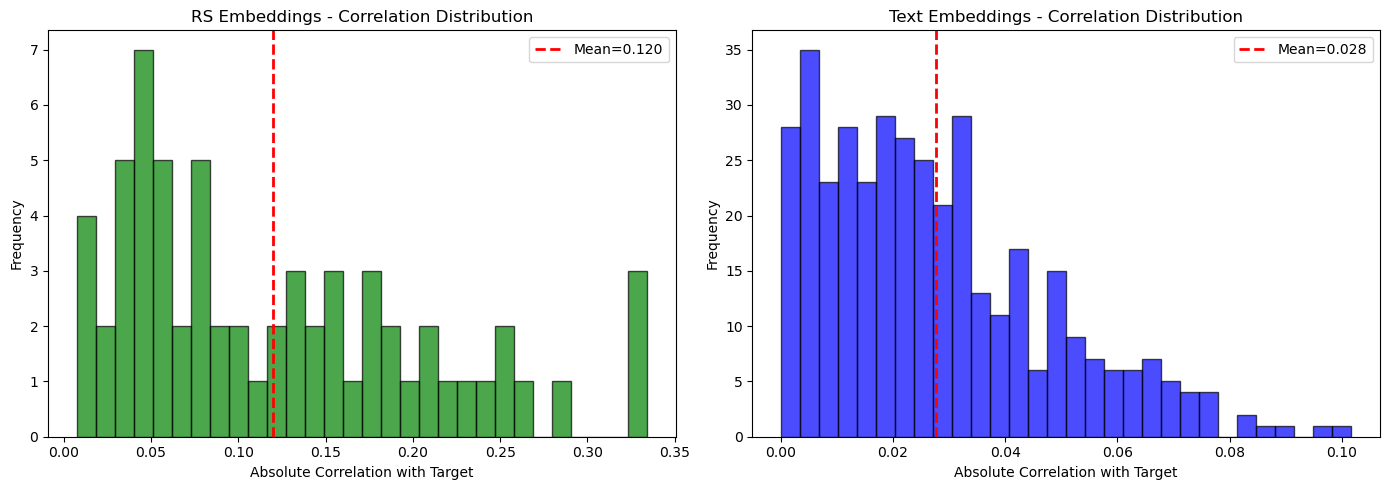


💡 Observaciones:
- ¿Los embeddings de texto tienen correlación casi nula con el target?
- Esto explicaría el R² negativo: no hay relación lineal con el éxito


In [15]:
# 5. Correlación entre embeddings y target
print("\n" + "="*70)
print("CORRELACIÓN EMBEDDINGS VS TARGET")
print("="*70)

# Calcular correlación de cada dimensión con el target
y_subset = target_subset.set_index('item_idx').loc[game_texts['item_idx']]['total_reviews'].values

corr_rs = []
for i in range(rs_emb_subset.shape[1]):
    corr = np.corrcoef(rs_emb_subset[:, i], y_subset)[0, 1]
    corr_rs.append(abs(corr))  # Valor absoluto

corr_text = []
for i in range(embeddings.shape[1]):
    corr = np.corrcoef(embeddings[:, i], y_subset)[0, 1]
    corr_text.append(abs(corr))

corr_rs = np.array(corr_rs)
corr_text = np.array(corr_text)

print(f"\nRS Embeddings:")
print(f"  Correlación promedio:   {np.nanmean(corr_rs):.4f}")
print(f"  Max correlación:        {np.nanmax(corr_rs):.4f}")
print(f"  Dims con corr > 0.1:    {np.sum(corr_rs > 0.1)}/{len(corr_rs)}")

print(f"\nText Embeddings:")
print(f"  Correlación promedio:   {np.nanmean(corr_text):.4f}")
print(f"  Max correlación:        {np.nanmax(corr_text):.4f}")
print(f"  Dims con corr > 0.1:    {np.sum(corr_text > 0.1)}/{len(corr_text)}")

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(corr_rs, bins=30, color='green', alpha=0.7, edgecolor='black')
ax1.axvline(np.nanmean(corr_rs), color='red', linestyle='--', linewidth=2, label=f'Mean={np.nanmean(corr_rs):.3f}')
ax1.set_xlabel('Absolute Correlation with Target')
ax1.set_ylabel('Frequency')
ax1.set_title('RS Embeddings - Correlation Distribution')
ax1.legend()

ax2.hist(corr_text, bins=30, color='blue', alpha=0.7, edgecolor='black')
ax2.axvline(np.nanmean(corr_text), color='red', linestyle='--', linewidth=2, label=f'Mean={np.nanmean(corr_text):.3f}')
ax2.set_xlabel('Absolute Correlation with Target')
ax2.set_ylabel('Frequency')
ax2.set_title('Text Embeddings - Correlation Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n💡 Observaciones:")
print("- ¿Los embeddings de texto tienen correlación casi nula con el target?")
print("- Esto explicaría el R² negativo: no hay relación lineal con el éxito")

## Summary: Why Text Embeddings Fail - CONCLUSIONES

**Análisis de los resultados:**

### 1. ✅ Cobertura de datos: NO ES EL PROBLEMA
- 100% de juegos tienen reviews text
- Distribuciones idénticas (media=16.1, std=107.75)
- **No hay sesgo de selección**

### 2. ❌ PROBLEMA CRÍTICO: Varianza 7x menor
- **RS embeddings**: varianza promedio = 0.0132
- **Text embeddings**: varianza promedio = 0.0019
- **Ratio: 0.144x** → Los embeddings de texto tienen **7 veces menos varianza**
- Embeddings muy similares entre sí = **poca capacidad discriminativa**

### 3. ❌ PROBLEMA CRÍTICO: Correlación 4.3x menor
- **RS embeddings**: 
  - Correlación promedio = 0.120
  - Max correlación = 0.334
  - **31/64 dimensiones** (48%) con corr > 0.1
- **Text embeddings**: 
  - Correlación promedio = 0.028 (4.3x menor)
  - Max correlación = 0.102
  - **Solo 1/384 dimensiones** (0.26%) con corr > 0.1
- Las dimensiones de texto **no capturan señales de popularidad**

### 4. 🎯 Interpretación: ¿Por qué?
Los embeddings de texto de reviews capturan **contenido semántico** (opiniones, características del juego) pero **NO** capturan los factores que impulsan el éxito comercial:
- Las reviews describen **qué piensan los jugadores** (calidad, diversión, bugs)
- Pero el éxito depende de **factores de marketing, timing, precio, viralidad**
- Los embeddings RS capturan **patrones colectivos de comportamiento** (qué juegos atrae a qué usuarios)

### 🏆 Conclusión para la tesis:
**"El contenido textual de las reviews refleja opiniones cualitativas sobre el juego, pero no predice su éxito cuantitativo. Los embeddings colaborativos (RS) capturan patrones de comportamiento colectivo que son 4-7 veces más predictivos del éxito comercial que el análisis semántico NLP del contenido de reviews."**

**Implicación práctica:**
- Para **recomendar** juegos a usuarios: usar embeddings RS (collaborative filtering)
- Para **analizar sentimiento** o calidad: usar embeddings de texto (NLP)
- **No** usar reviews text para predecir popularidad/ventas